In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

plt.rcParams['svg.fonttype'] = 'none'

In [3]:
df1 = pd.read_csv('../Data/cells_concat_raw-1.csv')
df2 = pd.read_csv('../Data/cells_concat_raw-2.csv')
df  = pd.concat([df1, df2])

### Data filters

## Removing cells dominated by background and cells reaching saturation
#df = df[df['directA_cell_max'] >= 250] 
df = df[df['directA_cell_max'] <= 65000] 

## Removing cells that are too circular (likely dying)
df = df[df['circ_cell_original'] < 0.8]
df = df[df['circ_cell_original'] > 0.3]
## Removing cells that have a very large nucleus in comparison to total area (likely dying), or they are segmented incorrectly (common in condensate formers)
df = df[df['nuc_area_ratio'] < .75]
df = df[df['nuc_area_ratio'] > .05]
## Removing cells with negative A_cell_corr - weird stuff going on or too close to background
df = df[df['A_cell_corr'] > 0]
## removing very small cells and/or debris
df = df[df['area_cell'] > 2000]
df = df[df['area_cell'] < 25000]

df = df[df['area_nuc'] < 5000]
df = df[df['area_nuc'] > 600]

df['window']   = df['construct'].str.extract(r'^(\d+-\d+)_')
df['mutation'] = df['construct'].str.extract(r'^[\d-]+_(.+)$')

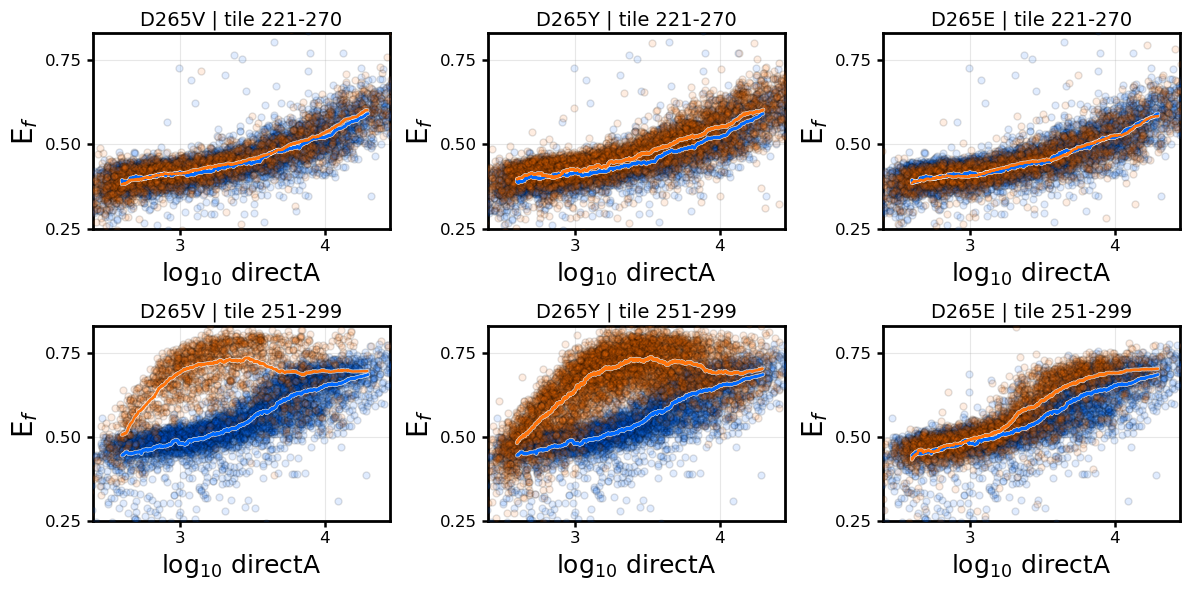

In [58]:
MUTANTS  = ['D265V', 'D265Y', 'D265E']
WINDOWS  = ['221-270', '251-299']
WT_COL   = '#006AFF'
MUT_COL  = '#FF730A'
ROLL_N   = 200
X_START, X_END = 2.6, 4.3

SUBPLOT_W, SUBPLOT_H = 4, 3
fig, axes = plt.subplots(
    len(WINDOWS), len(MUTANTS),
    figsize=(SUBPLOT_W * len(MUTANTS), SUBPLOT_H * len(WINDOWS)),
)

for row_idx, window in enumerate(WINDOWS):
    wdf = df[df['window'] == window].copy()

    for col_idx, mut in enumerate(MUTANTS):
        ax = axes[row_idx][col_idx]

        for vals, color, label in [
            (wdf[wdf['mutation'] == 'WT'], WT_COL,  'WT'),
            (wdf[wdf['mutation'] == mut],  MUT_COL, mut),
        ]:
            sub = vals[['log_directA_cell', 'Ef_cell']].dropna().copy()
            if sub.empty:
                continue

            ax.scatter(sub['log_directA_cell'], sub['Ef_cell'],
                       color=color, alpha=.12, s=25,
                       edgecolors='black', linewidths=1,
                       label=f'{label} (n={len(sub)})', zorder=3)

            # Clip rolling mean to [X_START, X_END]
            sub_sorted = sub.sort_values('log_directA_cell')
            roll_y = sub_sorted['Ef_cell'].rolling(
                ROLL_N, center=True, min_periods=10).mean()
            clip_mask = (sub_sorted['log_directA_cell'] >= X_START) & \
                        (sub_sorted['log_directA_cell'] <= X_END)
            rx = sub_sorted.loc[clip_mask, 'log_directA_cell']
            ry = roll_y[clip_mask]

            # White outline (drawn first, behind)
            ax.plot(rx, ry, color='white', linewidth=3, alpha=.6,
                    zorder=6, solid_capstyle='round')
            # Coloured line on top
            ax.plot(rx, ry, color=color, linewidth=1.7, alpha=1.0,
                    zorder=7, solid_capstyle='round')

        # Thicken spines
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        ax.set_xlim(2.4, 4.45)
        ax.set_ylim(.25, .83)
        ax.set_yticks([0.25, 0.50, 0.75])
        ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=12)
        ax.set_xticks([3, 4])
        ax.set_xticklabels(['3', '4'], fontsize=12)
        ax.tick_params(axis='both', which='both', width=1.8, length=4)
        ax.set_xlabel(r'log$_{10}$ directA', fontsize=18)
        ax.set_ylabel(r'E$_f$', fontsize=20)
        ax.set_title(f'{mut} | tile {window}', fontsize=14)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/trev/Downloads/interomlecularEf1.png', dpi=300)
plt.show()